In [7]:
import os, shutil, random
from pathlib import Path

KAGGLE = "/home/sakshi/dataset_new"
MRL    = "/home/sakshi/mrl_dataset"
OUT    = "/home/sakshi/dataset_combined"
SPLIT  = 0.85

if os.path.exists(OUT):
    shutil.rmtree(OUT)

for s in ["train","test"]:
    for c in ["open","closed","yawn","no_yawn"]:
        os.makedirs(f"{OUT}/{s}/{c}", exist_ok=True)

def split_copy(src, train_dst, test_dst, ratio=0.85):
    imgs = [f for f in Path(src).glob("*") if f.suffix.lower() in [".jpg",".jpeg",".png",".bmp"]]
    random.shuffle(imgs)
    n = int(len(imgs)*ratio)
    for f in imgs[:n]: shutil.copy2(str(f), train_dst)
    for f in imgs[n:]: shutil.copy2(str(f), test_dst)
    return len(imgs[:n]), len(imgs[n:])

random.seed(42)

# Kaggle
for kaggle_name, out_name in [("Open","open"),("Closed","closed"),("yawn","yawn"),("no_yawn","no_yawn")]:
    for split in ["train","test"]:
        src = f"{KAGGLE}/{split}/{kaggle_name}"
        dst = f"{OUT}/{split}/{out_name}"
        if os.path.exists(src):
            imgs = list(Path(src).glob("*"))
            for f in imgs: shutil.copy2(str(f), dst)
            print(f"Kaggle {split}/{out_name}: {len(imgs)}")
        else:
            print(f"WARNING: {src} not found")

# MRL
for mrl_name, out_name in [("Open_Eyes","open"),("Closed_Eyes","closed")]:
    src = f"{MRL}/{mrl_name}"
    tr, te = split_copy(src, f"{OUT}/train/{out_name}", f"{OUT}/test/{out_name}")
    print(f"MRL {out_name} — train:{tr}, test:{te}")

# Count
print("\n── Final Count ──")
total = 0
for s in ["train","test"]:
    for c in ["open","closed","yawn","no_yawn"]:
        n = len(list(Path(f"{OUT}/{s}/{c}").glob("*")))
        total += n
        print(f"  {s}/{c}: {n}")
print(f"Total: {total}")

Kaggle train/open: 617
Kaggle test/open: 109
Kaggle train/closed: 617
Kaggle test/closed: 109
Kaggle train/yawn: 617
Kaggle test/yawn: 106
Kaggle train/no_yawn: 616
Kaggle test/no_yawn: 109
MRL open — train:1700, test:300
MRL closed — train:1700, test:300

── Final Count ──
  train/open: 2317
  train/closed: 2317
  train/yawn: 617
  train/no_yawn: 616
  test/open: 409
  test/closed: 409
  test/yawn: 106
  test/no_yawn: 109
Total: 6900


In [8]:
DATA_DIR = "/home/sakshi/dataset_combined"

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

In [10]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.2,
    shear_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2]
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    f"{DATA_DIR}/train",
    target_size=(64, 64),
    color_mode="grayscale",
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    f"{DATA_DIR}/test",
    target_size=(64,64),
    color_mode="grayscale",
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

print("Classes:", train_gen.class_indices)
print("Train samples:", train_gen.samples)
print("Test samples:", val_gen.samples)

Found 5867 images belonging to 4 classes.
Found 1033 images belonging to 4 classes.
Classes: {'closed': 0, 'no_yawn': 1, 'open': 2, 'yawn': 3}
Train samples: 5867
Test samples: 1033


In [11]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation="relu", padding="valid",
                 kernel_regularizer=l2(0.0001),
                 input_shape=(64,64, 1)))
model.add(MaxPooling2D((2,2),strides = 2,padding = "same"))
model.add(Dropout(0.2))

model.add(Conv2D(64, (3,3), activation="relu", padding="same",
                 kernel_regularizer=l2(0.0001)))
model.add(MaxPooling2D((2,2),strides = 2,padding = "same"))
model.add(Dropout(0.2))

model.add(Conv2D(64, (3,3), activation="relu", padding="same",
                 kernel_regularizer=l2(0.0001)))
model.add(MaxPooling2D((2,2),strides = 2, padding = "same"))
model.add(Dropout(0.2))

model.add(Flatten())
model.add(Dense(256, activation="relu"))
model.add(Dropout(0.2))
model.add(Dense(4, activation="softmax"))

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/home/sakshi/tf-gpu/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1783212295.851078     894 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1754 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 4GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 31, 31, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,105,604 (4.22 MB)

 Trainable params: 1,105,604 (4.22 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
train_counts = np.array([2317, 616, 2317, 617])  # closed, no_yawn, open, yawn
total = train_counts.sum()
class_weights = {i: total / (4 * train_counts[i]) for i in range(4)}
print("Class weights:", class_weights)

Class weights: {0: np.float64(0.6330384117393181), 1: np.float64(2.3810876623376624), 2: np.float64(0.6330384117393181), 3: np.float64(2.377228525121556)}


In [13]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    ]


In [14]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=100,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 1/100


I0000 00:00:1783212320.271270     894 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1783212322.575329   17008 service.cc:153] XLA service 0x7e054c034590 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783212322.575386   17008 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 4GB Laptop GPU, Compute Capability 8.6 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.2)
I0000 00:00:1783212322.640189   17008 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1783212322.899240   17008 cuda_dnn.cc:461] Loaded cuDNN version 92302
I0000 00:00:1783212322.997803   17008 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2519__.51


  2/184 ━━━━━━━━━━━━━━━━━━━━ 12s 70ms/step - accuracy: 0.2500 - loss: 1.2715 

I0000 00:00:1783212330.357427   17008 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 77/184 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.4046 - loss: 1.0833

I0000 00:00:1783212333.234458   17008 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2519__.51


184/184 ━━━━━━━━━━━━━━━━━━━━ 27s 92ms/step - accuracy: 0.5860 - loss: 0.8100 - val_accuracy: 0.8316 - val_loss: 0.4770
Epoch 2/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.8226 - loss: 0.4949 - val_accuracy: 0.8606 - val_loss: 0.3448
Epoch 3/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.8503 - loss: 0.4417 - val_accuracy: 0.8858 - val_loss: 0.2587
Epoch 4/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accuracy: 0.8497 - loss: 0.4317 - val_accuracy: 0.8838 - val_loss: 0.2882
Epoch 5/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.8698 - loss: 0.4135 - val_accuracy: 0.8906 - val_loss: 0.2405
Epoch 6/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.8737 - loss: 0.4053 - val_accuracy: 0.8906 - val_loss: 0.2267
Epoch 7/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.8853 - loss: 0.3791 - val_accuracy: 0.9080 - val_loss: 0.1904
Epoch 8/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.8926 - loss: 0.3718 - val_accurac

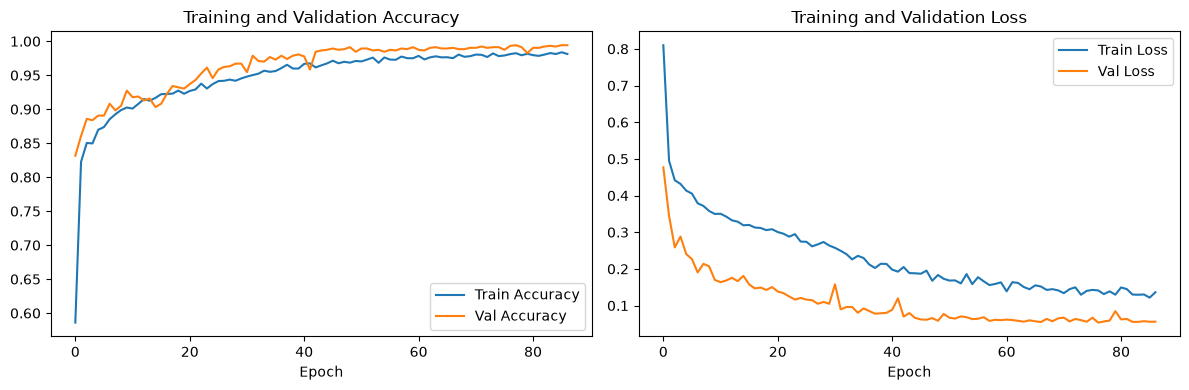

In [15]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.savefig("training_curves_combined.png")
plt.show()

33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step


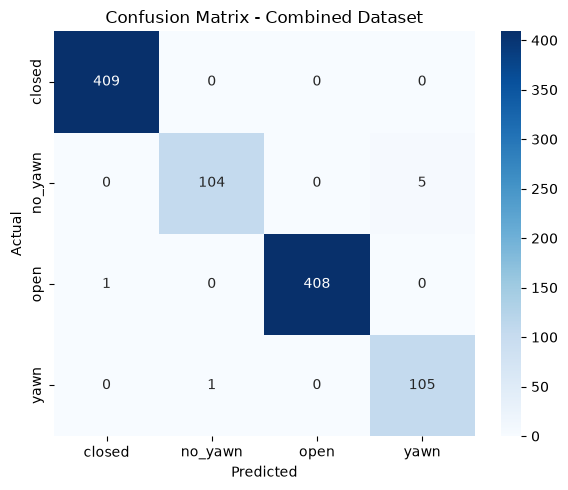


Classification Report:
              precision    recall  f1-score   support

      closed       1.00      1.00      1.00       409
     no_yawn       0.99      0.95      0.97       109
        open       1.00      1.00      1.00       409
        yawn       0.95      0.99      0.97       106

    accuracy                           0.99      1033
   macro avg       0.99      0.99      0.99      1033
weighted avg       0.99      0.99      0.99      1033



In [16]:
val_gen.reset()
y_pred = np.argmax(model.predict(val_gen), axis=1)
y_true = val_gen.classes

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=list(train_gen.class_indices.keys()),
            yticklabels=list(train_gen.class_indices.keys()))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Combined Dataset")
plt.tight_layout()
plt.savefig("confusion_matrix_combined.png")
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred,
      target_names=list(train_gen.class_indices.keys())))

In [25]:
model.save("drowsiness_final2.h5")

In [6]:
from pathlib import Path

OUT = "/home/sakshi/dataset_combined"
print("── Original Dataset Count ──")
for s in ["train", "test"]:
    for c in ["open", "closed", "yawn", "no_yawn"]:
        n = len(list(Path(f"{OUT}/{s}/{c}").glob("*")))
        print(f"  {s}/{c}: {n}")

── Original Dataset Count ──
  train/open: 2317
  train/closed: 2317
  train/yawn: 617
  train/no_yawn: 616
  test/open: 409
  test/closed: 409
  test/yawn: 106
  test/no_yawn: 109


In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

model = load_model('/home/sakshi/drowsiness_final.h5')
IMG_SIZE = 64

# Yawn wali photo
img = cv2.imread('/home/sakshi/test_yawn.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
resized = cv2.resize(gray, (IMG_SIZE, IMG_SIZE))
tensor  = (resized / 255.0).reshape(1, 64,64, 1)

pred = model.predict(tensor, verbose=0)[0]

print("Raw softmax output:")
print(f"  closed  (0): {pred[0]:.4f}")
print(f"  no_yawn (1): {pred[1]:.4f}")
print(f"  open    (2): {pred[2]:.4f}")
print(f"  yawn    (3): {pred[3]:.4f}")
print(f"\nyawn vs no_yawn: {'YAWN' if pred[3] > pred[1] else 'NO YAWN'}")

Raw softmax output:
  closed  (0): 0.0269
  no_yawn (1): 0.0551
  open    (2): 0.0966
  yawn    (3): 0.8214

yawn vs no_yawn: YAWN
